# Compare Auction Values

In [1]:
import pandas as pd
pd.options.display.precision = 2
from matplotlib import colors
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
Pitching_Pos = 'SP'

#Jan23 2025 Roster totals
Replacement_Level = {
    'SP':150,
    #'Util':233,

}
Replacement_window = {
    'SP':5,
}

In [3]:
# ADP First
Proj_cols = ['ADP_FGAV','TOTAL_SGP_Val_mySGP', 'Dollars_FGAV', 'Dollars_Vibbot']

In [4]:
#Scoring Categories
# Count_Scoring_Categories_Batting = [
#     'R',
#     'HR'
# ]
# Rate_Scoring_Categories_Batting = [
#     'OBP',
#     'SLG'
# ]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
# Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
# Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [5]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [6]:
Replacement_Calc_date = 'Jan31_2026'

In [7]:
Full_Merge_path = League_path+'/Full_Merge.csv'

In [8]:
Replacement_Level_Recalc_path = League_path+'/Recalc_Replacement_Level.csv'

In [9]:
Repl_Level_H_path = League_path+'/Latest_Hitter_Repl.csv'
Repl_Level_P_path = League_path+'/Latest_Pitcher_Repl.csv'

In [10]:
Replacement_Level_Recalc_df = pd.read_csv(Replacement_Level_Recalc_path)

In [11]:
Replacement_Level_Orig_df = pd.concat([
    pd.read_csv(Repl_Level_H_path),
    pd.read_csv(Repl_Level_P_path)
])

In [12]:
Both_Replacement_Level_df = Replacement_Level_Recalc_df.merge(Replacement_Level_Orig_df,how='outer')#.set_index('Ottoneu Positions')

In [13]:
Both_Replacement_Level_df.head()

,Ottoneu Positions,HR_SGP_Val_mySGP,HR_SGP_norm_mySGP,HR_SGP_raw_mySGP,HR_mySGP,OBP_SGP_Val_mySGP,OBP_SGP_norm_mySGP,OBP_SGP_raw_mySGP,OBP_mySGP,R_SGP_Val_mySGP,...,SV,TBF,W,SO_SGP_raw,HR9,HR9_SGP_raw,ERA,ERA_SGP_raw,WHIP,WHIP_SGP_raw
0,1B,3.99,2.30e-01,1.61,18.54,12.29,0.23,-5.11e-03,0.33,4.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2B,2.22,1.28e-01,1.10,12.64,6.07,0.11,-8.23e-02,0.32,5.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3B,7.09,4.08e-01,1.54,17.69,7.30,0.14,-6.64e-02,0.32,7.78,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C,1.29,7.40e-02,1.10,12.67,6.29,0.12,-1.38e-01,0.31,3.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MI,-0.17,-9.86e-03,0.95,10.94,0.55,0.01,-1.74e-01,0.31,0.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
Player_id_cols = [
    'FG ID','Name','Team','Ottoneu ID','Ottoneu Positions'
]

In [15]:
Fantasy_Team_ID_cols = [
    'TeamID', 'Team Name',
]

In [16]:
Full_Merge_df = pd.read_csv(Full_Merge_path)
Full_Merge_df['FG ID'] = Full_Merge_df['FG ID'].astype(str)
Full_Merge_df['FG ID'] = Full_Merge_df['FG ID'].str.replace('.0','')
Full_Merge_df['Ottoneu ID'] = Full_Merge_df['Ottoneu ID'].astype(str)
Full_Merge_df['Ottoneu ID'] = Full_Merge_df['Ottoneu ID'].str.replace('.0','')

In [17]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [18]:
Full_Merge_sorted_df = Full_Merge_df.sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

In [19]:
Full_Merge_sorted_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : Pitching_Pos in x.split('/'))]

In [20]:
Full_Merge_df.head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary
0,10061,NYM,60.70,NaN,NaN,50.97,NaN,NaN,NaN,7.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10078,CHC,65.71,NaN,NaN,54.64,NaN,NaN,NaN,7.95,...,NaN,3.0,3.0,3.0,3.0,1.0,29.17,NaN,NaN,NaN
2,10155,LAA,129.14,556.38,472.47,113.94,65.56,19.01,1.92,27.45,...,20.6,35.7,35.0,17.0,72.0,32.7,83.33,NaN,NaN,NaN
3,10197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4.8,4.0,3.0,7.0,1.5,20.83,NaN,NaN,NaN
4,10231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
Full_Merge_sorted_df['TOTAL_SGP_PosRank_mySGP'] = Full_Merge_sorted_df['TOTAL_SGP_Rank_mySGP'].rank()

In [ ]:
#https://www.cbssports.com/fantasy/baseball/news/2026-fantasy-baseball-draft-prep-second-base-tiers-1-0-tiered-rankings-for-this-years-weakest-position/

Tiers = [
    {'Ottoneu ID':'35204', 'Name':"Tarik Skubal",'Tier':1}, 
    {'Ottoneu ID':'38312', 'Name':"Garrett Crochet",'Tier':1}, 
    {'Ottoneu ID':'43894', 'Name':"Paul Skenes",'Tier':1}, 

    {'Ottoneu ID':'14393', 'Name':"Chris Sale",'Tier':2}, 
    {'Ottoneu ID':'44525', 'Name':"Yoshinobu Yamamoto",'Tier':2}, 
    {'Ottoneu ID':'33682', 'Name':"Logan Gilbert",'Tier':2}, 
    {'Ottoneu ID':'20975', 'Name':"Cristopher Sanchez",'Tier':2}, 
    {'Ottoneu ID':'41042', 'Name':"Bryan Woo",'Tier':2}, 
    {'Ottoneu ID':'18164', 'Name':"Max Fried",'Tier':2}, 
    {'Ottoneu ID':'37201', 'Name':"Hunter Brown",'Tier':2}, 
    {'Ottoneu ID':'23824', 'Name':"Hunter Greene",'Tier':2}, 
    {'Ottoneu ID':'23625', 'Name':"Cole Ragans",'Tier':2}, 
    {'Ottoneu ID':'18460', 'Name':"Blake Snell",'Tier':2}, 
    {'Ottoneu ID':'14294', 'Name':"Jacob deGrom",'Tier':2}, 
    {'Ottoneu ID':'21015', 'Name':"Logan Webb",'Tier':2}, 
    {'Ottoneu ID':'22426', 'Name':"Framber Valdez",'Tier':2},

    {'Ottoneu ID':'42737', 'Name':"Spencer Schwellenbach",'Tier':3},
    {'Ottoneu ID':'23741', 'Name':"Jesus Luzardo",'Tier':3},
    {'Ottoneu ID':'19168', 'Name':"Freddy Peralta",'Tier':3},
    {'Ottoneu ID':'36671', 'Name':"George Kirby",'Tier':3},
    {'Ottoneu ID':'35874', 'Name':"Kyle Bradish",'Tier':3},
    {'Ottoneu ID':'35196', 'Name':"Joe Ryan",'Tier':3},
    {'Ottoneu ID':'33600', 'Name':"Shohei Ohtani",'Tier':3},
    {'Ottoneu ID':'18236', 'Name':"Tyler Glasnow",'Tier':3},
    {'Ottoneu ID':'38559', 'Name':"Eury Perez",'Tier':3},
    {'Ottoneu ID':'21052', 'Name':"Dylan Cease",'Tier':3},
    {'Ottoneu ID':'19398', 'Name':"Nick Pivetta",'Tier':3},

    {'Ottoneu ID':'23693', 'Name':"Brandon Woodruff",'Tier':4},
    {'Ottoneu ID':'33607', 'Name':"Trevor Rogers",'Tier':4},
    {'Ottoneu ID':'38736', 'Name':"Spencer Strider",'Tier':4},
    {'Ottoneu ID':'45706', 'Name':"Chase Burns",'Tier':4},
    {'Ottoneu ID':'18196', 'Name':"Kevin Gausman",'Tier':4},
    {'Ottoneu ID':'36686', 'Name':"Nick Lodolo",'Tier':4},
    {'Ottoneu ID':'40941', 'Name':"Gavin Williams",'Tier':4},
    {'Ottoneu ID':'44336', 'Name':"Nolan McLean",'Tier':4},
    {'Ottoneu ID':'45790', 'Name':"Trey Yesavage",'Tier':4},
    {'Ottoneu ID':'43589', 'Name':"Cam Schlittler",'Tier':4},

    {'Ottoneu ID':'23814', 'Name':"Shane Bieber",'Tier':5},
    {'Ottoneu ID':'15962', 'Name':"Zack Wheeler",'Tier':5},
    {'Ottoneu ID':'9335', 'Name':"Nathan Eovaldi",'Tier':5},
    {'Ottoneu ID':'40564', 'Name':"Bubba Chandler",'Tier':5},
    {'Ottoneu ID':'42711', 'Name':"Jacob Misiorowski",'Tier':5},
    {'Ottoneu ID':'40552', 'Name':"Emmet Sheehan",'Tier':5},
    {'Ottoneu ID':'48241', 'Name':"Tatsuya Imai",'Tier':5},
    {'Ottoneu ID':'14941', 'Name':"Robbie Ray",'Tier':5},
    {'Ottoneu ID':'18786', 'Name':"Pablo Lopez",'Tier':5},
    {'Ottoneu ID':'31751', 'Name':"Michael King",'Tier':5},
    {'Ottoneu ID':'31194', 'Name':"Ranger Suarez",'Tier':5},
    {'Ottoneu ID':'35566', 'Name':"Kris Bubic",'Tier':5},
    {'Ottoneu ID':'18113', 'Name':"Sonny Gray",'Tier':5},
    {'Ottoneu ID':'23732', 'Name':"Luis Castillo",'Tier':5},
    {'Ottoneu ID':'20732', 'Name':"Sandy Alcantara",'Tier':5},
    {'Ottoneu ID':'42719', 'Name':"Cade Horton",'Tier':5},
    {'Ottoneu ID':'44526', 'Name':"Shota Imanaga",'Tier':5},
    {'Ottoneu ID':'35922', 'Name':"Drew Rasmussen",'Tier':5},
    {'Ottoneu ID':'40978', 'Name':"Tanner Bibee",'Tier':5},
    {'Ottoneu ID':'37649', 'Name':"Ryan Pepiot",'Tier':5},
    {'Ottoneu ID':'18359', 'Name':"Carlos Rodon",'Tier':5},

    {'Ottoneu ID':'33325', 'Name':"Edward Cabrera",'Tier':6},
    {'Ottoneu ID':'40607', 'Name':"Andrew Abbott",'Tier':6},
    {'Ottoneu ID':'18465', 'Name':"Matthew Boyd",'Tier':6},
    {'Ottoneu ID':'18462', 'Name':"Joe Musgrove",'Tier':6},
    {'Ottoneu ID':'18116', 'Name':"Gerrit Cole",'Tier':6},
    {'Ottoneu ID':'23810', 'Name':"MacKenzie Gore",'Tier':6},
    {'Ottoneu ID':'33612', 'Name':"Grayson Rodriguez",'Tier':6},
    {'Ottoneu ID':'46091', 'Name':"Roki Sasaki",'Tier':6},
    {'Ottoneu ID':'17763', 'Name':"Merrill Kelly",'Tier':6},
    {'Ottoneu ID':'33647', 'Name':"Shane McClanahan",'Tier':6},
    {'Ottoneu ID':'18357', 'Name':"Aaron Nola",'Tier':6},
    {'Ottoneu ID':'23779', 'Name':"Zac Gallen",'Tier':6},
    {'Ottoneu ID':'44515', 'Name':"Connelly Early",'Tier':6},
    {'Ottoneu ID':'37826', 'Name':"Ryne Nelson",'Tier':6},
    {'Ottoneu ID':'36682', 'Name':"Quinn Priester",'Tier':6},
    {'Ottoneu ID':'43879', 'Name':"Hurston Waldrep",'Tier':6},
    {'Ottoneu ID':'23794', 'Name':"Shane Baz",'Tier':6},
    {'Ottoneu ID':'42765', 'Name':"Parker Messick",'Tier':6},
    {'Ottoneu ID':'42592', 'Name':"Shane Smith",'Tier':6},
    {'Ottoneu ID':'40937', 'Name':"Noah Cameron",'Tier':6},
    {'Ottoneu ID':'35696', 'Name':"Jacob Lopez",'Tier':6},
    {'Ottoneu ID':'18257', 'Name':"Sean Manaea",'Tier':6},
    {'Ottoneu ID':'40155', 'Name':"Jack Leiter",'Tier':6},
    {'Ottoneu ID':'33670', 'Name':"Ryan Weathers",'Tier':6},

    {'Ottoneu ID':'40550', 'Name':"Bryce Miller",'Tier':7},
    {'Ottoneu ID':'20920', 'Name':"Jack Flaherty",'Tier':7},
    {'Ottoneu ID':'42723', 'Name':"Kodai Senga",'Tier':7},
    {'Ottoneu ID':'47725', 'Name':"Jared Jones",'Tier':7},
    {'Ottoneu ID':'35808', 'Name':"Reese Olson",'Tier':7},
    {'Ottoneu ID':'38328', 'Name':"Reid Detmers",'Tier':7},
    {'Ottoneu ID':'19422', 'Name':"Tyler Mahle",'Tier':7},
    {'Ottoneu ID':'32966', 'Name':"Bailey Ober",'Tier':7},
    {'Ottoneu ID':'42653', 'Name':"Zebby Matthews",'Tier':7},
    {'Ottoneu ID':'42741', 'Name':"Robby Snelling",'Tier':7},
    {'Ottoneu ID':'42312', 'Name':"Logan Henderson",'Tier':7},
    {'Ottoneu ID':'27148', 'Name':"Joey Cantillo",'Tier':7},
    {'Ottoneu ID':'14906', 'Name':"Jameson Taillon",'Tier':7},
    {'Ottoneu ID':'19437', 'Name':"Zack Littell",'Tier':7},
    {'Ottoneu ID':'18195', 'Name':"Lucas Giolito",'Tier':7},
    {'Ottoneu ID':'33767', 'Name':"Brayan Bello",'Tier':7},
    {'Ottoneu ID':'23701', 'Name':"Seth Lugo",'Tier':7},
    {'Ottoneu ID':'33616', 'Name':"Casey Mize",'Tier':7},
    {'Ottoneu ID':'33620', 'Name':"Brady Singer",'Tier':7},
    {'Ottoneu ID':'31541', 'Name':"David Peterson",'Tier':7},
    {'Ottoneu ID':'18171', 'Name':"Michael Wacha",'Tier':7},
    {'Ottoneu ID':'32009', 'Name':"Jose Soriano",'Tier':7},
    {'Ottoneu ID':'21961', 'Name':"Cody Ponce",'Tier':7},
    {'Ottoneu ID':'35776', 'Name':"Braxton Ashcraft",'Tier':7},
    {'Ottoneu ID':'18415', 'Name':"Reynaldo Lopez",'Tier':7},
    {'Ottoneu ID':'43275', 'Name':"Luis Morales",'Tier':7},
    {'Ottoneu ID':'20936', 'Name':"Mitch Keller",'Tier':7},
    {'Ottoneu ID':'18201', 'Name':"Jose Berrios",'Tier':7},
    {'Ottoneu ID':'21039', 'Name':"Justin Steele",'Tier':7},
    {'Ottoneu ID':'18375', 'Name':"Grant Holmes",'Tier':7},
    {'Ottoneu ID':'43841', 'Name':"Jonah Tong",'Tier':7},
    {'Ottoneu ID':'38409', 'Name':"Ian Seymour",'Tier':7},
    {'Ottoneu ID':'18398', 'Name':"Chris Bassitt",'Tier':7},
    {'Ottoneu ID':'32804', 'Name':"Tyler Wells",'Tier':7},
    {'Ottoneu ID':'38307', 'Name':"Max Meyer",'Tier':7},
    {'Ottoneu ID':'23813', 'Name':"Corbin Burnes",'Tier':7},
    {'Ottoneu ID':'44534', 'Name':"Brandon Sproat",'Tier':7},
    {'Ottoneu ID':'38397', 'Name':"Joe Boyle",'Tier':7},
    {'Ottoneu ID':'35367', 'Name':"Taj Bradley",'Tier':7},
    {'Ottoneu ID':'38334', 'Name':"Cade Cavalli",'Tier':7},
    {'Ottoneu ID':'35811', 'Name':"Mike Burrows",'Tier':7},
    {'Ottoneu ID':'23373', 'Name':"Luis Gil",'Tier':7},
    {'Ottoneu ID':'23790', 'Name':"Clay Holmes",'Tier':7},
    {'Ottoneu ID':'23612', 'Name':"Zach Eflin",'Tier':7},
    {'Ottoneu ID':'22694', 'Name':"Cristian Javier",'Tier':7}
]

my_cmap = {1:'tab:blue',
           2:'tab:orange',
           3:'tab:green',
           4:'tab:red',
           5:'tab:purple',
           6:'tab:brown',
           7:'tab:pink',
           8:'tab:grey',
           9:'tab:olive',
           10:'tab:cyan'}

In [23]:
Full_Merge_sorted_df = Full_Merge_sorted_df.merge(pd.DataFrame(Tiers),on=['Ottoneu ID'],how='left',suffixes=['','_no_not_use'])

In [24]:
Full_Merge_sorted_df[['Name','Tier']]

,Name,Tier
0,Shohei Ohtani,3.0
1,Tarik Skubal,1.0
2,Paul Skenes,1.0
3,Garrett Crochet,1.0
4,Cristopher Sanchez,2.0
...,...,...
323,Jaxon Wiggins,NaN
324,Hagen Smith,NaN
325,Jurrangelo Cijntje,NaN
326,Gage Jump,NaN


In [25]:
# Full_Merge_df.fillna({'Tier':(Full_Merge_df['Tier'].max()+1)},inplace=True)

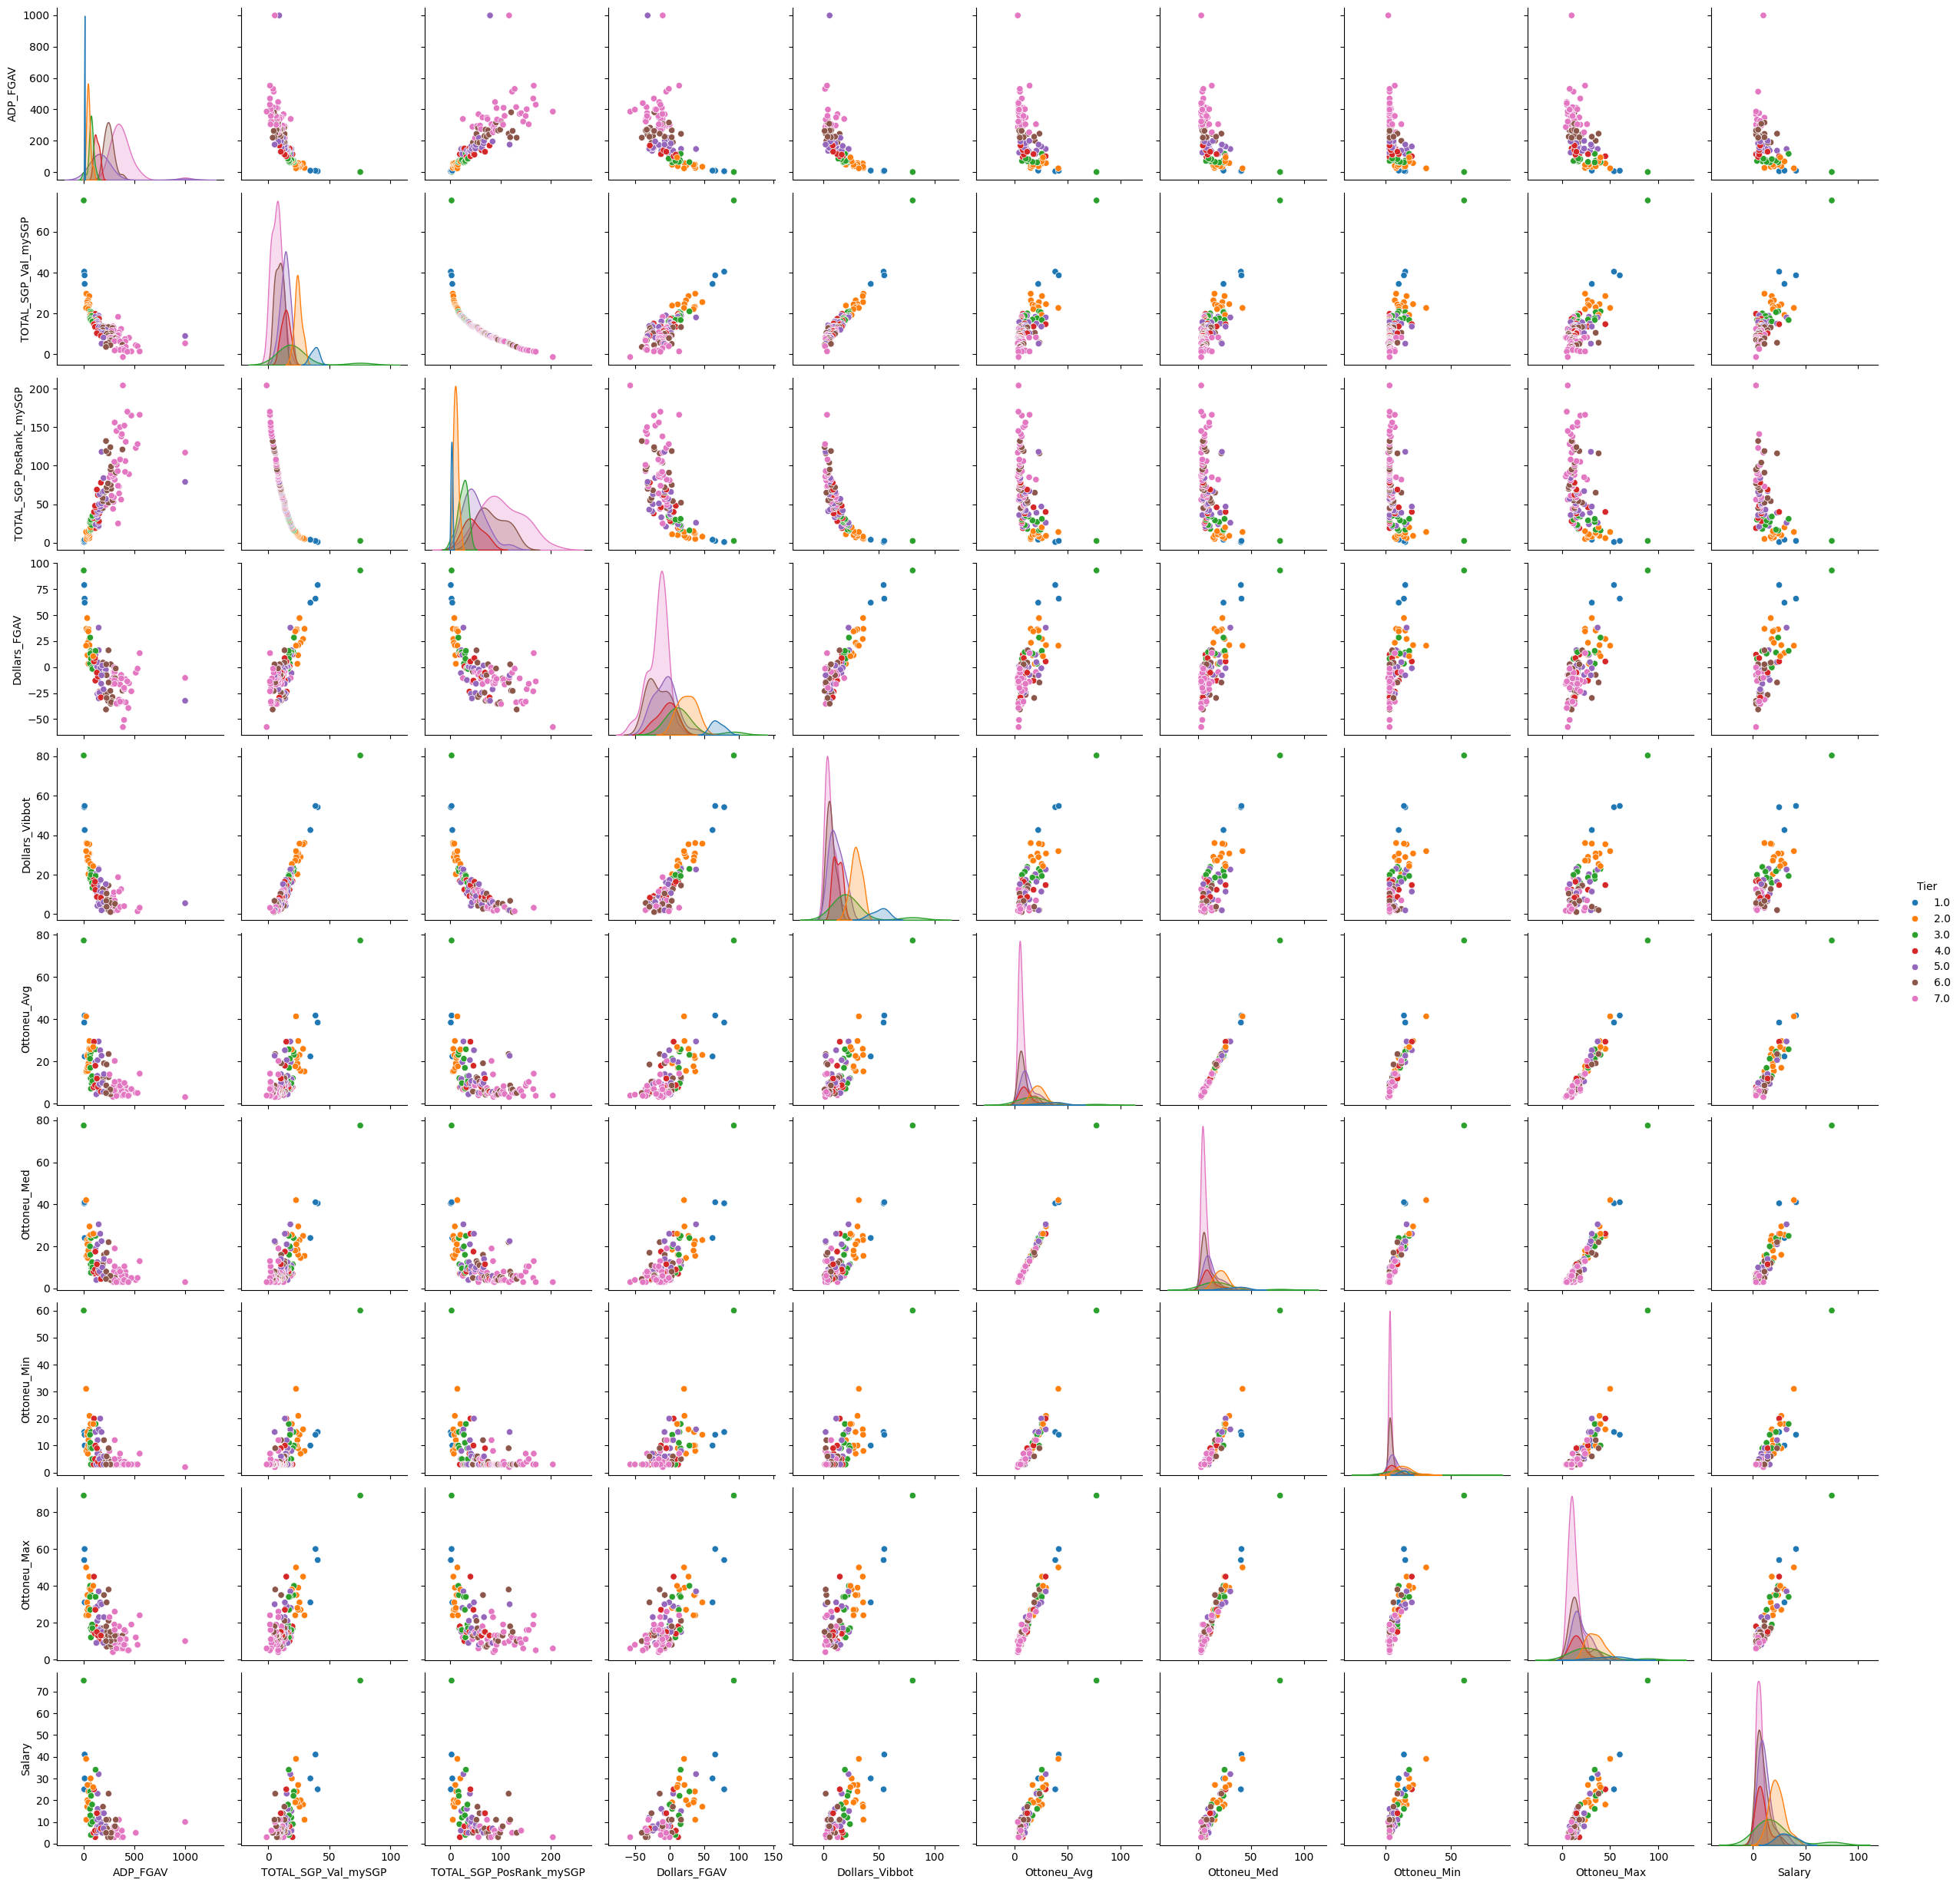

In [26]:
sns.pairplot(Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['ADP_FGAV'] <= 500) | \
    (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    (Full_Merge_sorted_df['Salary'] > 0.)][[
    'Name',
    'Team',
    'Ottoneu Positions',
    'Repl_Pos_mySGP',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'TOTAL_SGP_PosRank_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary',
    'Tier'
]],hue='Tier',palette="tab10")

In [27]:
list(Full_Merge_sorted_df.columns)

['FG ID',
 'Team',
 'G_mySGP',
 'PA_mySGP',
 'AB_mySGP',
 'H_mySGP',
 '1B_mySGP',
 '2B_mySGP',
 '3B_mySGP',
 'HR_mySGP',
 'R_mySGP',
 'RBI_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'SF_mySGP',
 'WAR_mySGP',
 'ADP_mySGP',
 'POS_mySGP',
 'Ottoneu ID',
 'Ottoneu Positions',
 'Name',
 'OBP_mySGP',
 'TB_mySGP',
 'SLG_mySGP',
 'Pos Place_mySGP',
 'R_SGP_raw_mySGP',
 'HR_SGP_raw_mySGP',
 'OBP_SGP_raw_mySGP',
 'SLG_SGP_raw_mySGP',
 'TOTAL_SGP_raw_mySGP',
 'R_SGP_repl_mySGP',
 'Repl_Pos_mySGP',
 'R_SGP_norm_mySGP',
 'HR_SGP_repl_mySGP',
 'HR_SGP_norm_mySGP',
 'OBP_SGP_repl_mySGP',
 'OBP_SGP_norm_mySGP',
 'SLG_SGP_repl_mySGP',
 'SLG_SGP_norm_mySGP',
 'TOTAL_SGP_mySGP',
 'TOTAL_SGP_Rank_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'R_SGP_Val_mySGP',
 'HR_SGP_Val_mySGP',
 'OBP_SGP_Val_mySGP',
 'SLG_SGP_Val_mySGP',
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'SO_mySGP',
 'HR9_mySGP',
 'ERA_mySGP',
 'WHIP_mySGP',
 'SO_SGP_raw_mySGP',
 'HR9_SGP_

In [28]:
quick_plot = Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['TOTAL_SGP_PosRank_mySGP'] <= Replacement_Level[Pitching_Pos]+Replacement_window[Pitching_Pos]) ]#| \
    # (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    # (Full_Merge_sorted_df['Salary'] > 0.)]

In [29]:
def quick_plotting_fn(quick_plot,ax1):
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    ax1.tick_params(axis='y', which='major', labelsize=7)
    return

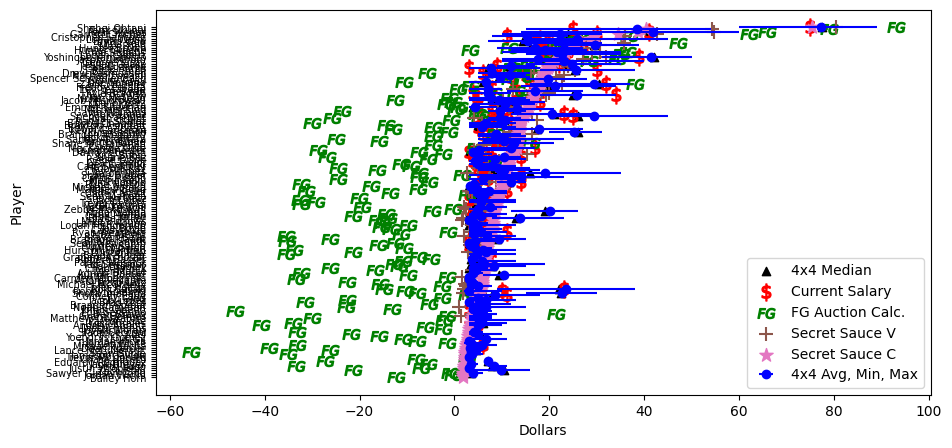

In [30]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
quick_plotting_fn(quick_plot,ax1)
plt.show()

###################################
Position SP Replacement Level = 150
###################################
Replacement Level ADP_FGAV SP 548.52 +- 7.40


,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary,TOTAL_SGP_PosRank_mySGP,Name_no_not_use,Tier,ADP_FGAV_SP_rank
147,13164,ARI,25.19,NaN,NaN,140.57,NaN,NaN,NaN,19.48,...,7.0,1.70,4.17,NaN,NaN,NaN,148.0,NaN,NaN,148.0
110,27572,PIT,34.75,NaN,NaN,69.76,NaN,NaN,NaN,7.67,...,3.0,1.14,4.17,NaN,NaN,NaN,111.0,NaN,NaN,149.0
165,19361,ARI,6.30,NaN,NaN,36.35,NaN,NaN,NaN,4.14,...,24.0,9.70,45.83,NaN,NaN,NaN,166.0,Corbin Burnes,7.0,150.0
102,29812,MIL,36.76,NaN,NaN,76.64,NaN,NaN,NaN,11.52,...,5.0,1.40,16.67,NaN,NaN,NaN,103.0,NaN,NaN,151.0
289,3137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.0,3.00,41.67,NaN,NaN,NaN,NaN,NaN,NaN,152.0


Replacement Level TOTAL_SGP_Val_mySGP SP 2.06 +- 0.12


,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Ottoneu_L10,Roster%,TeamID,Team Name,Salary,TOTAL_SGP_PosRank_mySGP,Name_no_not_use,Tier,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank
151,13774,BAL,25.51,NaN,NaN,150.76,NaN,NaN,NaN,22.50,...,3.5,33.33,NaN,NaN,NaN,152.0,Zach Eflin,7.0,116.0,152.0
150,31204,LAD,37.43,NaN,NaN,51.36,NaN,NaN,NaN,7.38,...,2.1,8.33,NaN,NaN,NaN,151.0,NaN,NaN,162.0,151.0
149,12447,KCR,27.34,NaN,NaN,160.96,NaN,NaN,NaN,22.87,...,4.6,41.67,NaN,NaN,NaN,150.0,Seth Lugo,7.0,103.0,150.0
148,30249,LAD,42.37,NaN,NaN,37.77,NaN,NaN,NaN,5.69,...,1.5,29.17,NaN,NaN,NaN,149.0,NaN,NaN,194.0,149.0
147,13164,ARI,25.19,NaN,NaN,140.57,NaN,NaN,NaN,19.48,...,1.7,4.17,NaN,NaN,NaN,148.0,NaN,NaN,148.0,148.0


Replacement Level Dollars_FGAV SP -11.69 +- 0.25


,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Roster%,TeamID,Team Name,Salary,TOTAL_SGP_PosRank_mySGP,Name_no_not_use,Tier,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank,Dollars_FGAV_SP_rank
187,30161,MIL,29.24,NaN,NaN,36.26,NaN,NaN,NaN,5.68,...,NaN,NaN,NaN,NaN,188.0,NaN,NaN,220.0,188.0,152.0
237,14916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.17,NaN,NaN,NaN,NaN,NaN,NaN,220.0,231.0,151.0
105,22543,MIN,38.70,NaN,NaN,111.98,NaN,NaN,NaN,16.18,...,50.00,NaN,NaN,NaN,106.0,Taj Bradley,7.0,118.0,106.0,150.0
179,31764,HOU,42.10,NaN,NaN,47.93,NaN,NaN,NaN,7.98,...,12.50,NaN,NaN,NaN,180.0,NaN,NaN,156.0,180.0,149.0
91,27474,MIA,32.72,NaN,NaN,133.52,NaN,NaN,NaN,17.71,...,58.33,NaN,NaN,NaN,92.0,Max Meyer,7.0,117.0,92.0,148.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_31340/826392948.py:112: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


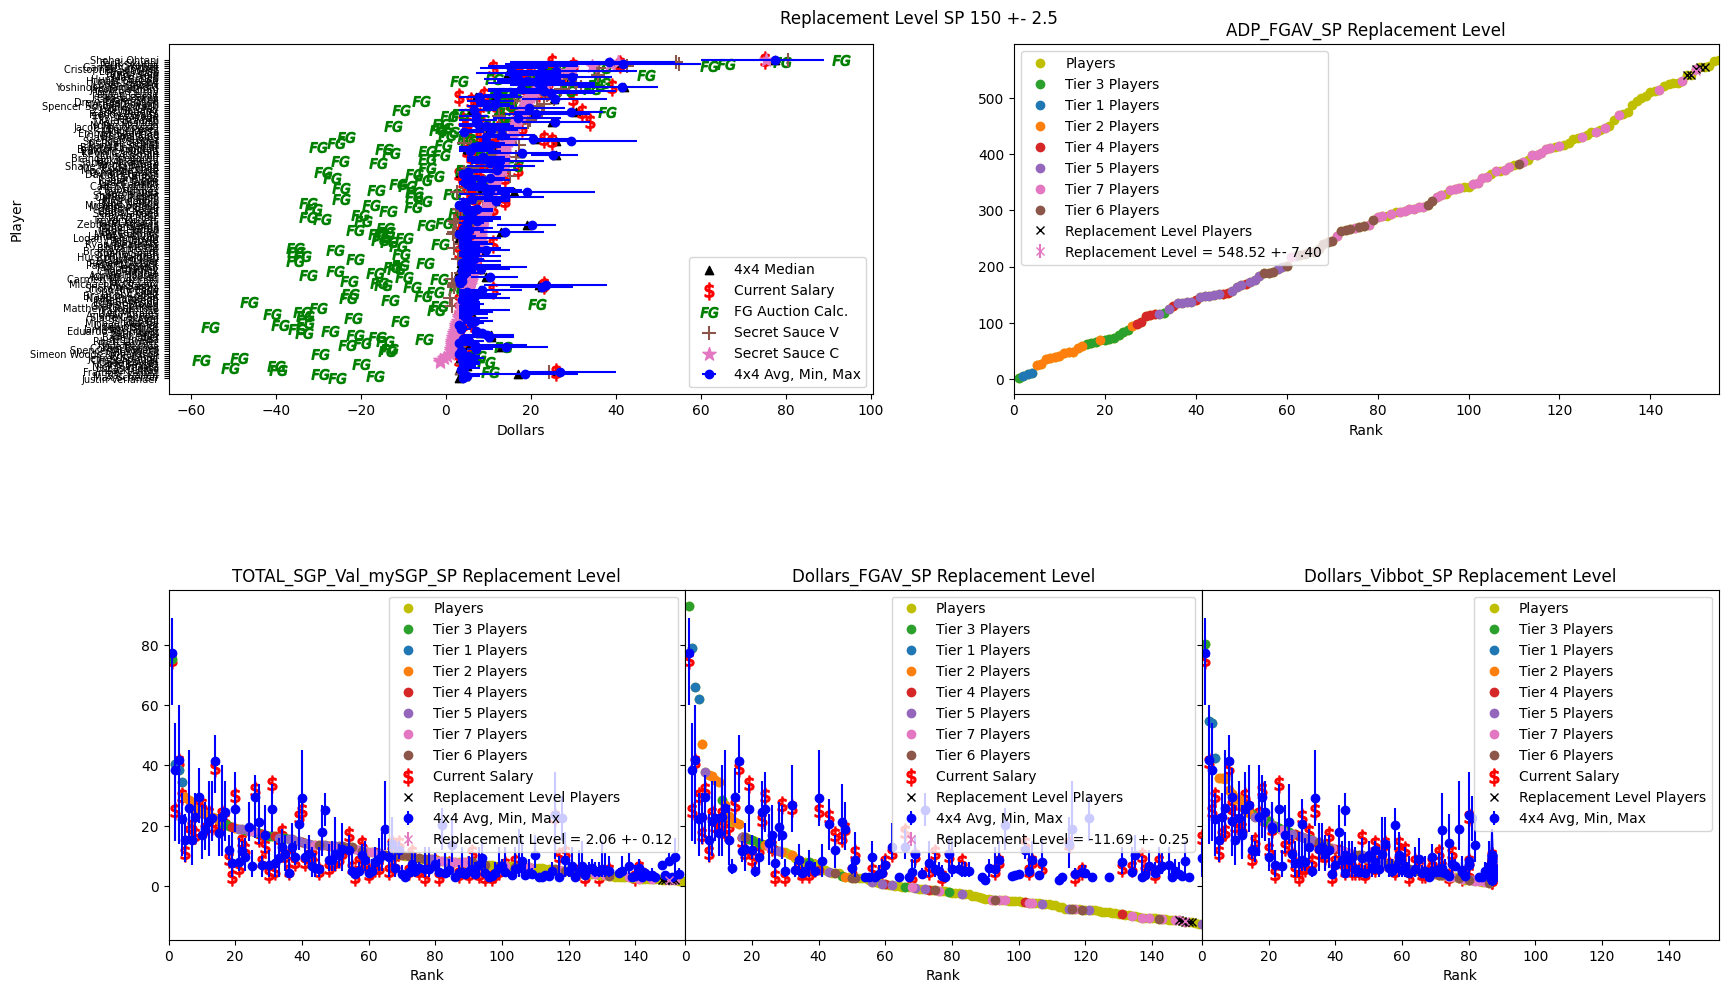

In [31]:
Replacement_Stats_df = pd.DataFrame()

pos_idx = 0

for pos,repl_level_mid in Replacement_Level.items():
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : pos in x.split('/'))]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Full_Merge_sorted_df[~Full_Merge_sorted_df['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"2B" in x.split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"SS" in x.split('/'))]

        ]).sort_values(by=['TOTAL_SGP_PosRank_mySGP']).drop_duplicates(keep='first')

    proj_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]
    fig0 = plt.figure(figsize=(20,10))
    outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
    upper_axes = outer_subfig[0].subplots(1, 2)
    lower_gs = outer_subfig[1].add_gridspec(1,len(Proj_cols)-1, wspace=0)
    lower_axes = lower_gs.subplots(sharey=True) # Because ADP is above
    #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))
    for proj_col in Proj_cols:
        this_axis = lower_axes[proj_idx-1]
        is_rank = False
        if 'ADP' in proj_col:
            is_rank = True
            this_axis = upper_axes[1]
        This_Pos_df[f'{proj_col}_{pos}_rank'] = This_Pos_df[f'{proj_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
        # this_axis = axs

        if proj_idx == 0:
            quick_plotting_fn(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max],upper_axes[0])
        
        Replacement_level_df = This_Pos_df[(This_Pos_df[f'{proj_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{proj_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ].sort_values([f'{proj_col}_{pos}_rank'], ascending=is_rank)
        mean = Replacement_level_df[proj_col].mean()
        std = Replacement_level_df[proj_col].std()
        Replacement_Stats_df = pd.concat([
            Replacement_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat': proj_col,
                'mean':mean,
                'std':std
            }])
        ])

        this_axis.plot(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col], 'yo', label='Players')
        for tier in list(This_Pos_df['Tier'].dropna().unique()):
            This_Pos_tier_df = This_Pos_df[This_Pos_df['Tier'] == tier]
            this_axis.plot(This_Pos_tier_df[This_Pos_tier_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],This_Pos_tier_df[This_Pos_tier_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col], marker='o', label=f'Tier {int(tier)} Players',color=my_cmap[tier],linestyle='')
        if not is_rank:
            this_axis.errorbar(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                yerr=[
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                ],
                fmt='o',
                color='blue',
                label='4x4 Avg, Min, Max'
            )
            this_axis.scatter(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Salary'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                marker='$\\$$',
                color='red',
                s=150,
                label='Current Salary'
            )
        if len(Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank']) > 0.:
            this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
            
            print(f'Replacement Level {proj_col} {pos} {mean:0.2f} +- {std:0.2f}')
            display(Replacement_level_df)
        this_axis.plot(Replacement_level_df[f'{proj_col}_{pos}_rank'],Replacement_level_df[proj_col], marker='x', color='k',label='Replacement Level Players',linestyle='')
        this_axis.set_title(f'{proj_col}_{pos} Replacement Level')
        #this_axis.set_ylabel(proj_col)
        this_axis.set_xlabel('Rank')
        # ymin = 0.95*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].min()
        # ymax = 1.05*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].max()
        xmin=0.
        xmax = x_max
        # this_axis.set_ylim([ymin,ymax])
        this_axis.set_xlim([xmin,xmax])
        this_axis.legend(loc='upper right')
        if is_rank:
            this_axis.legend(loc='upper left')

        #print(Replacement_level_df.head(Replacement_window[pos]))
        # quick_plotting_fn(Replacement_level_df,this_axis)
        # plt.tight_layout()    
        # plt.show()
        #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
        proj_idx+=1
    pos_idx+=1   
    fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
    plt.tight_layout()
    plt.show()

# Scoring Stat Level

In [32]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [33]:
Batting_value_columns = {
    'R':['TOTAL_SGP_Val_mySGP','R_mySGP','R_SGP_raw_mySGP','R_SGP_norm_mySGP','R_SGP_Val_mySGP','mR_FGAV'],
    'HR':['TOTAL_SGP_Val_mySGP','HR_mySGP','HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','HR_SGP_Val_mySGP','mHR_FGAV'],
    'OBP':['TOTAL_SGP_Val_mySGP','OBP_mySGP','OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','OBP_SGP_Val_mySGP','mOBP_FGAV'],
    'SLG':['TOTAL_SGP_Val_mySGP','SLG_mySGP','SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP','SLG_SGP_Val_mySGP','mSLG_FGAV']
}

Pitching_value_columns = {
    'SO':['TOTAL_SGP_Val_mySGP','SO_mySGP','SO_SGP_raw_mySGP','SO_SGP_norm_mySGP','SO_SGP_Val_mySGP','mSO_FGAV',],
    'HR9':['TOTAL_SGP_Val_mySGP','HR9_mySGP','HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP','HR9_SGP_Val_mySGP','mHR_FGAV',],
    'ERA':['TOTAL_SGP_Val_mySGP','ERA_mySGP','ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP','ERA_SGP_Val_mySGP','mERA_FGAV',],
    'WHIP':['TOTAL_SGP_Val_mySGP','WHIP_mySGP','WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP','WHIP_SGP_Val_mySGP','mWHIP_FGAV',]
}

In [34]:
All_Batting_cols = []
for stat,cols in Batting_value_columns.items():
    All_Batting_cols += cols
    All_Batting_cols = list(set(All_Batting_cols))

All_Pitching_cols = []
for stat,cols in Pitching_value_columns.items():
    All_Pitching_cols += cols
    All_Pitching_cols = list(set(All_Pitching_cols))

In [35]:
list(Full_Merge_df.columns)

['FG ID',
 'Team',
 'G_mySGP',
 'PA_mySGP',
 'AB_mySGP',
 'H_mySGP',
 '1B_mySGP',
 '2B_mySGP',
 '3B_mySGP',
 'HR_mySGP',
 'R_mySGP',
 'RBI_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'SF_mySGP',
 'WAR_mySGP',
 'ADP_mySGP',
 'POS_mySGP',
 'Ottoneu ID',
 'Ottoneu Positions',
 'Name',
 'OBP_mySGP',
 'TB_mySGP',
 'SLG_mySGP',
 'Pos Place_mySGP',
 'R_SGP_raw_mySGP',
 'HR_SGP_raw_mySGP',
 'OBP_SGP_raw_mySGP',
 'SLG_SGP_raw_mySGP',
 'TOTAL_SGP_raw_mySGP',
 'R_SGP_repl_mySGP',
 'Repl_Pos_mySGP',
 'R_SGP_norm_mySGP',
 'HR_SGP_repl_mySGP',
 'HR_SGP_norm_mySGP',
 'OBP_SGP_repl_mySGP',
 'OBP_SGP_norm_mySGP',
 'SLG_SGP_repl_mySGP',
 'SLG_SGP_norm_mySGP',
 'TOTAL_SGP_mySGP',
 'TOTAL_SGP_Rank_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'R_SGP_Val_mySGP',
 'HR_SGP_Val_mySGP',
 'OBP_SGP_Val_mySGP',
 'SLG_SGP_Val_mySGP',
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'SO_mySGP',
 'HR9_mySGP',
 'ERA_mySGP',
 'WHIP_mySGP',
 'SO_SGP_raw_mySGP',
 'HR9_SGP_

In [36]:
Sorted_Hitter_df = Full_Merge_sorted_df[~Full_Merge_sorted_df['Ottoneu Positions'].isin(['SP','RP','SP/RP'])][[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Repl_Pos_mySGP',
    'Tier',
    'Ottoneu ID',
    'ADP_FGAV',
    #'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary',
    'G_mySGP'
]+ All_Batting_cols].sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

Sorted_Pitcher_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(['SP','RP','SP/RP','Util/SP'])][[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Repl_Pos_mySGP',
    'Tier',
    'Ottoneu ID',
    'ADP_FGAV',
    #'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary',
    'IP_mySGP'
]+ All_Pitching_cols].sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

###################################
Position SP Replacement Level = 150
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_31340/178189501.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


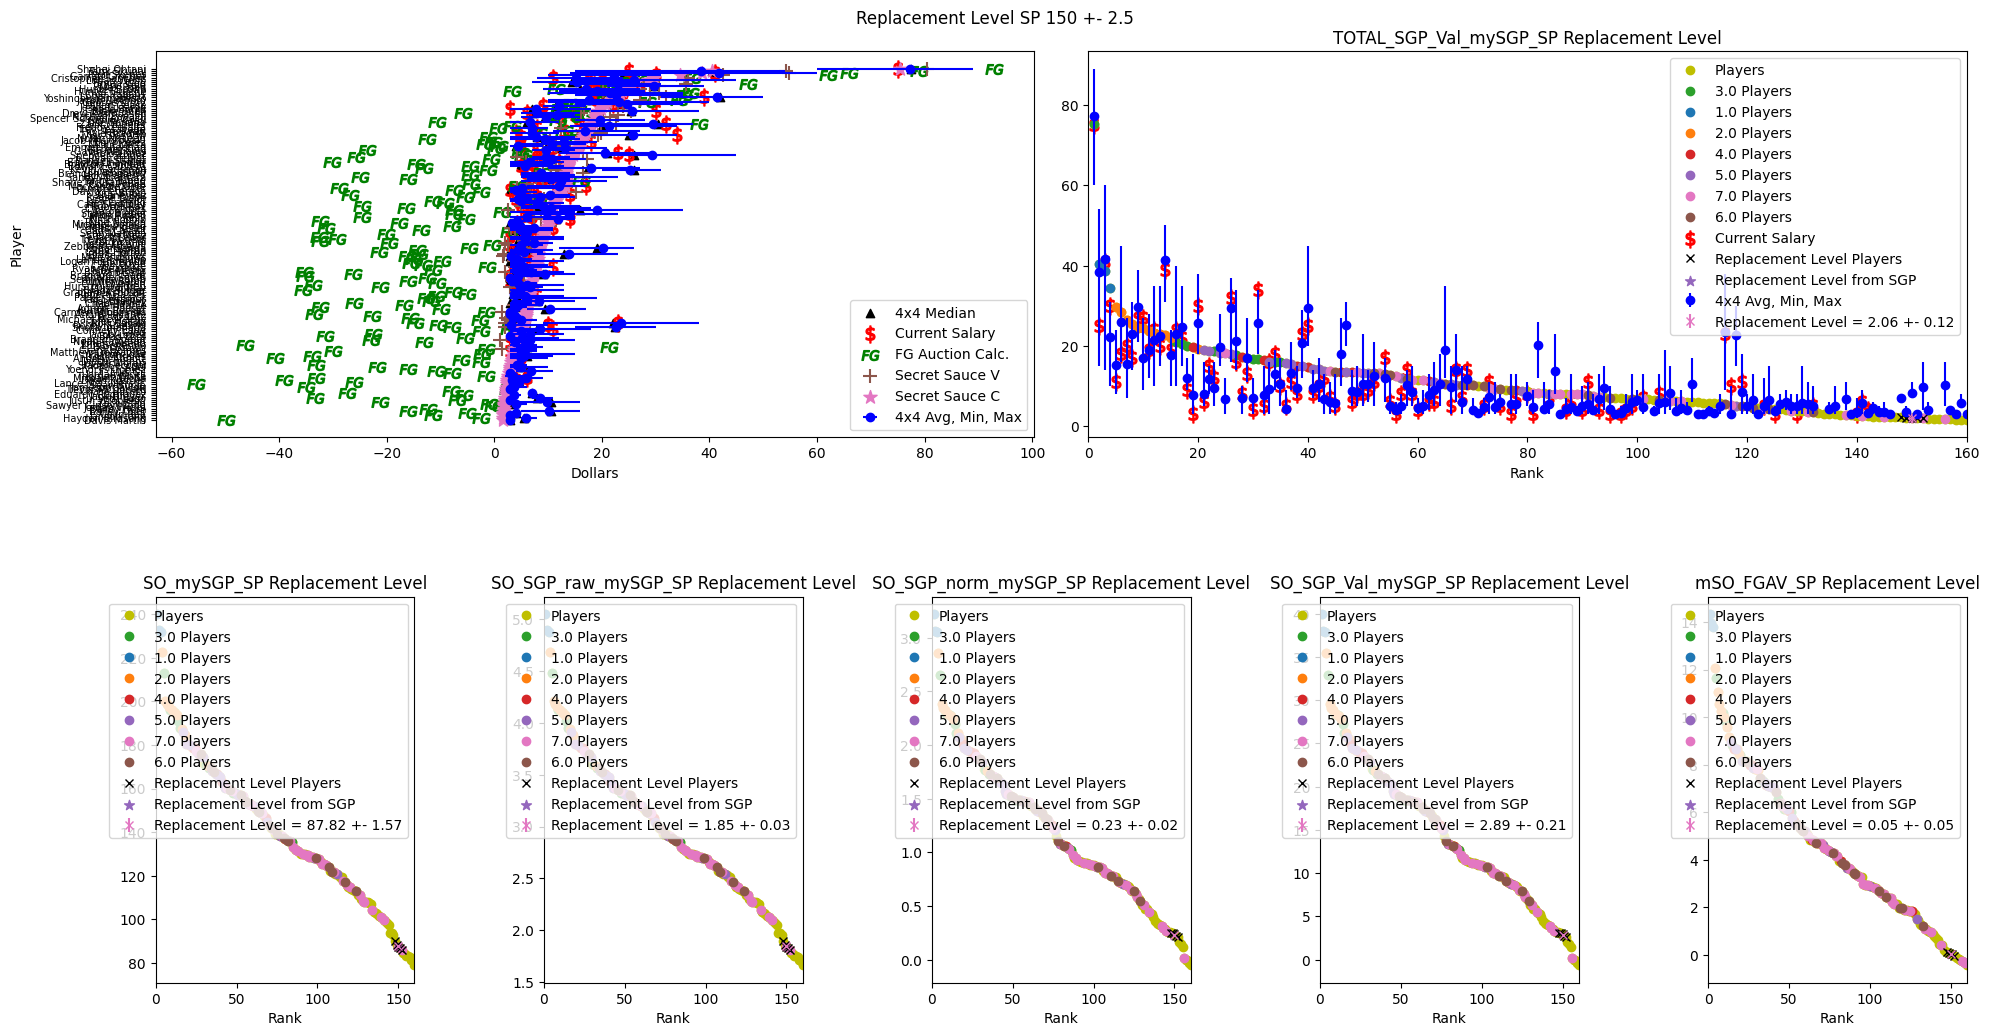

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_31340/178189501.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


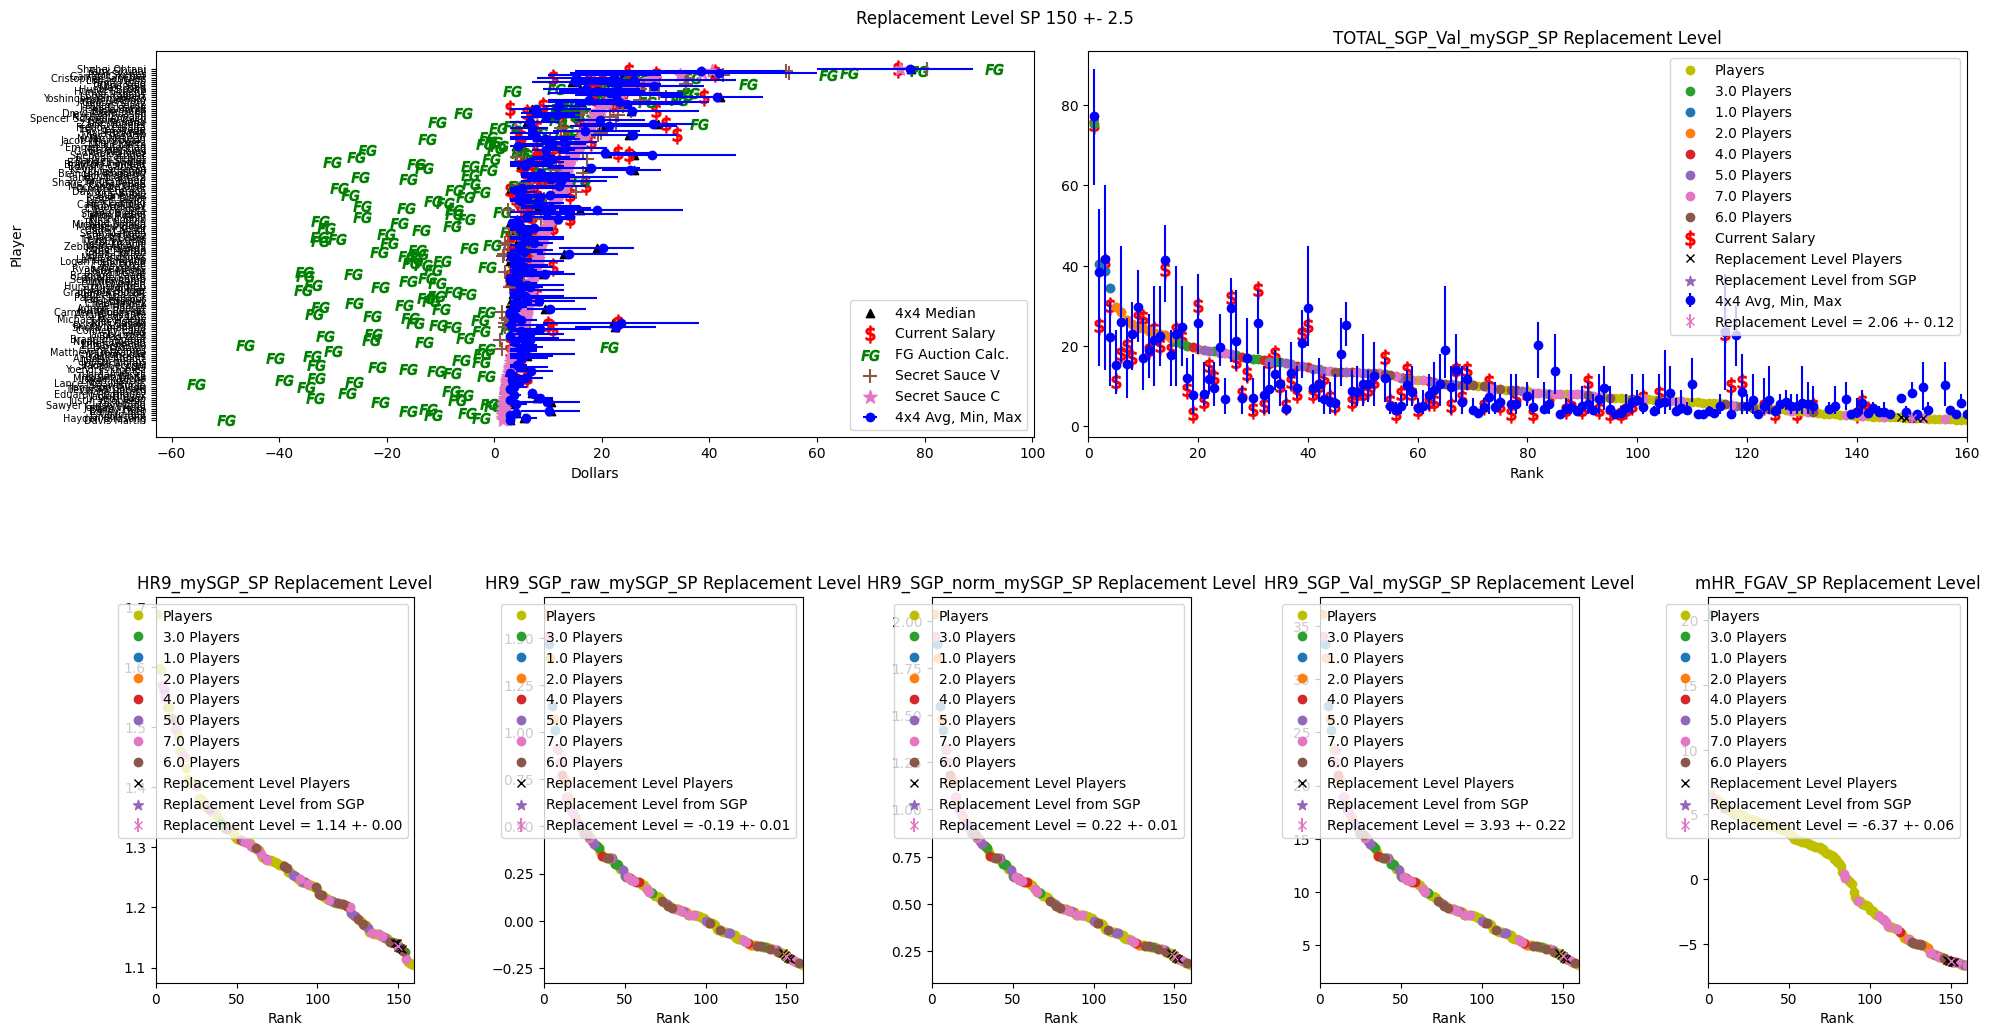

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_31340/178189501.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


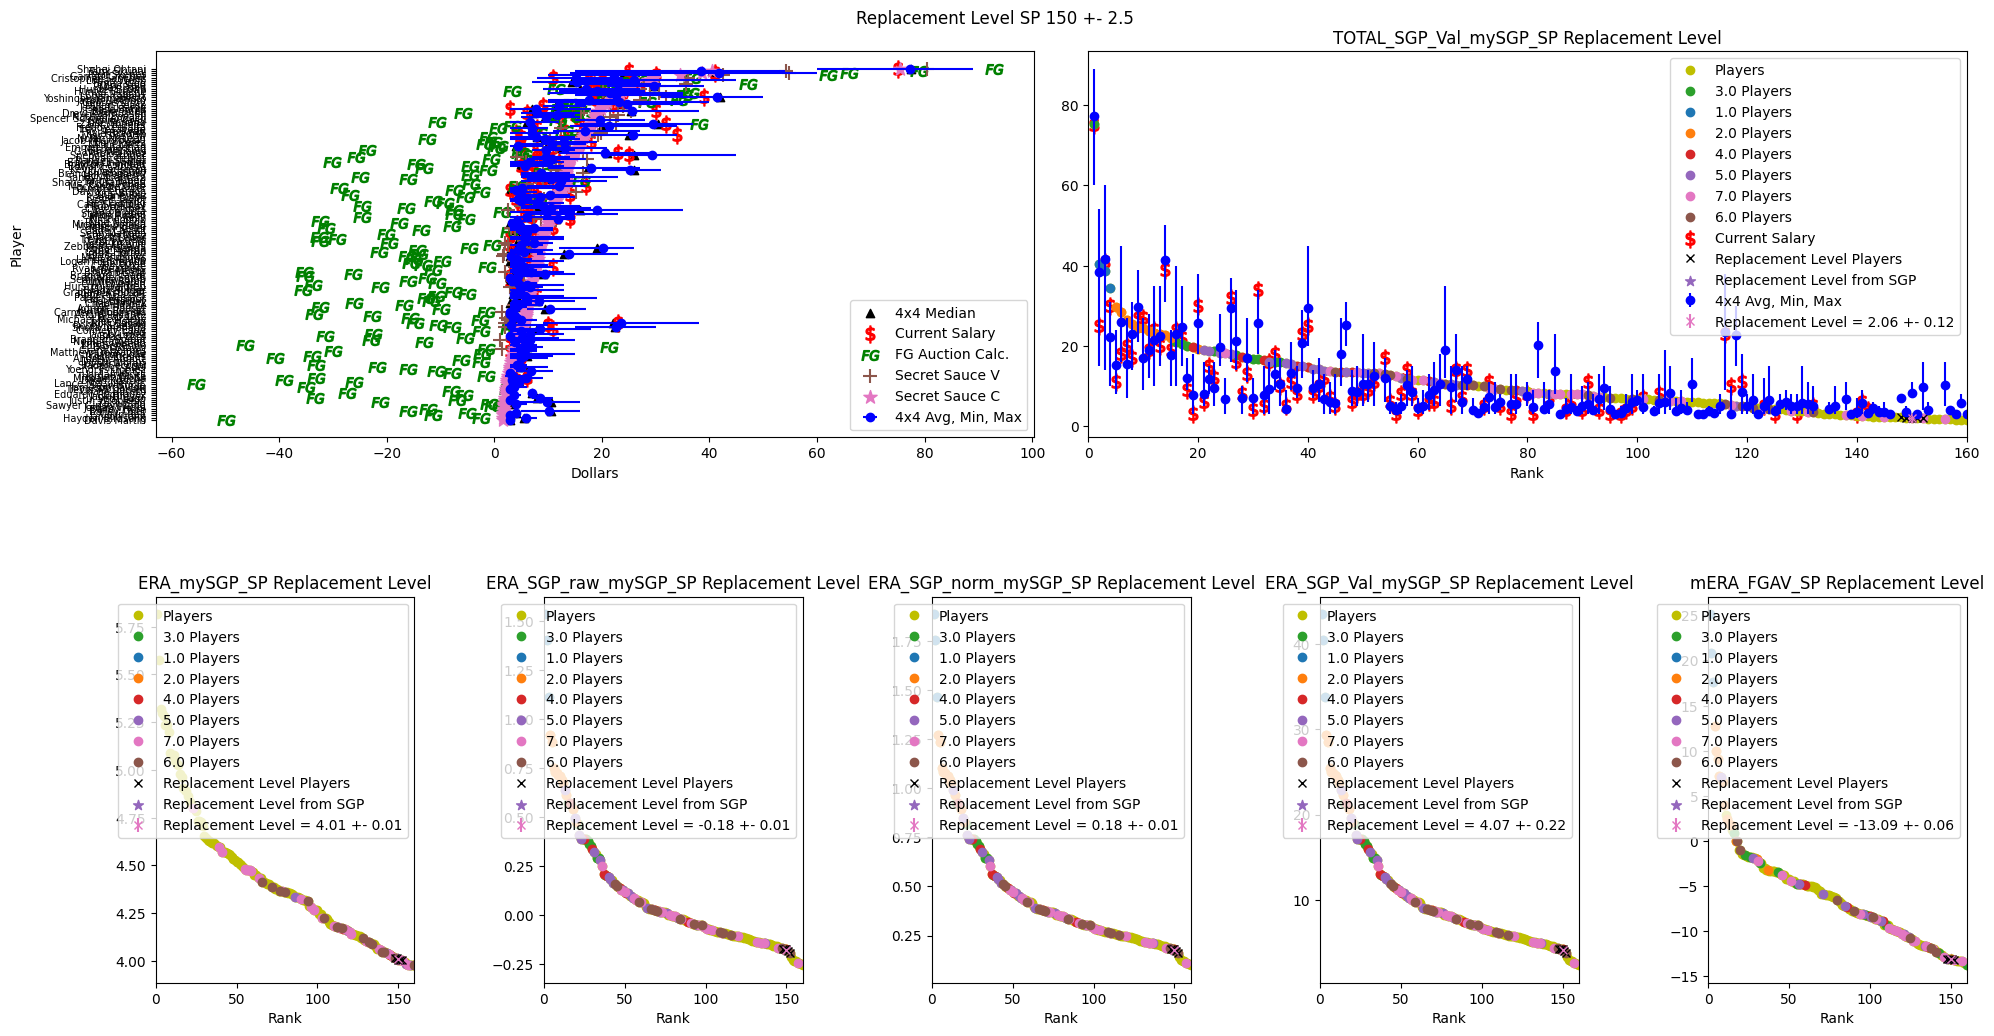

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_31340/178189501.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


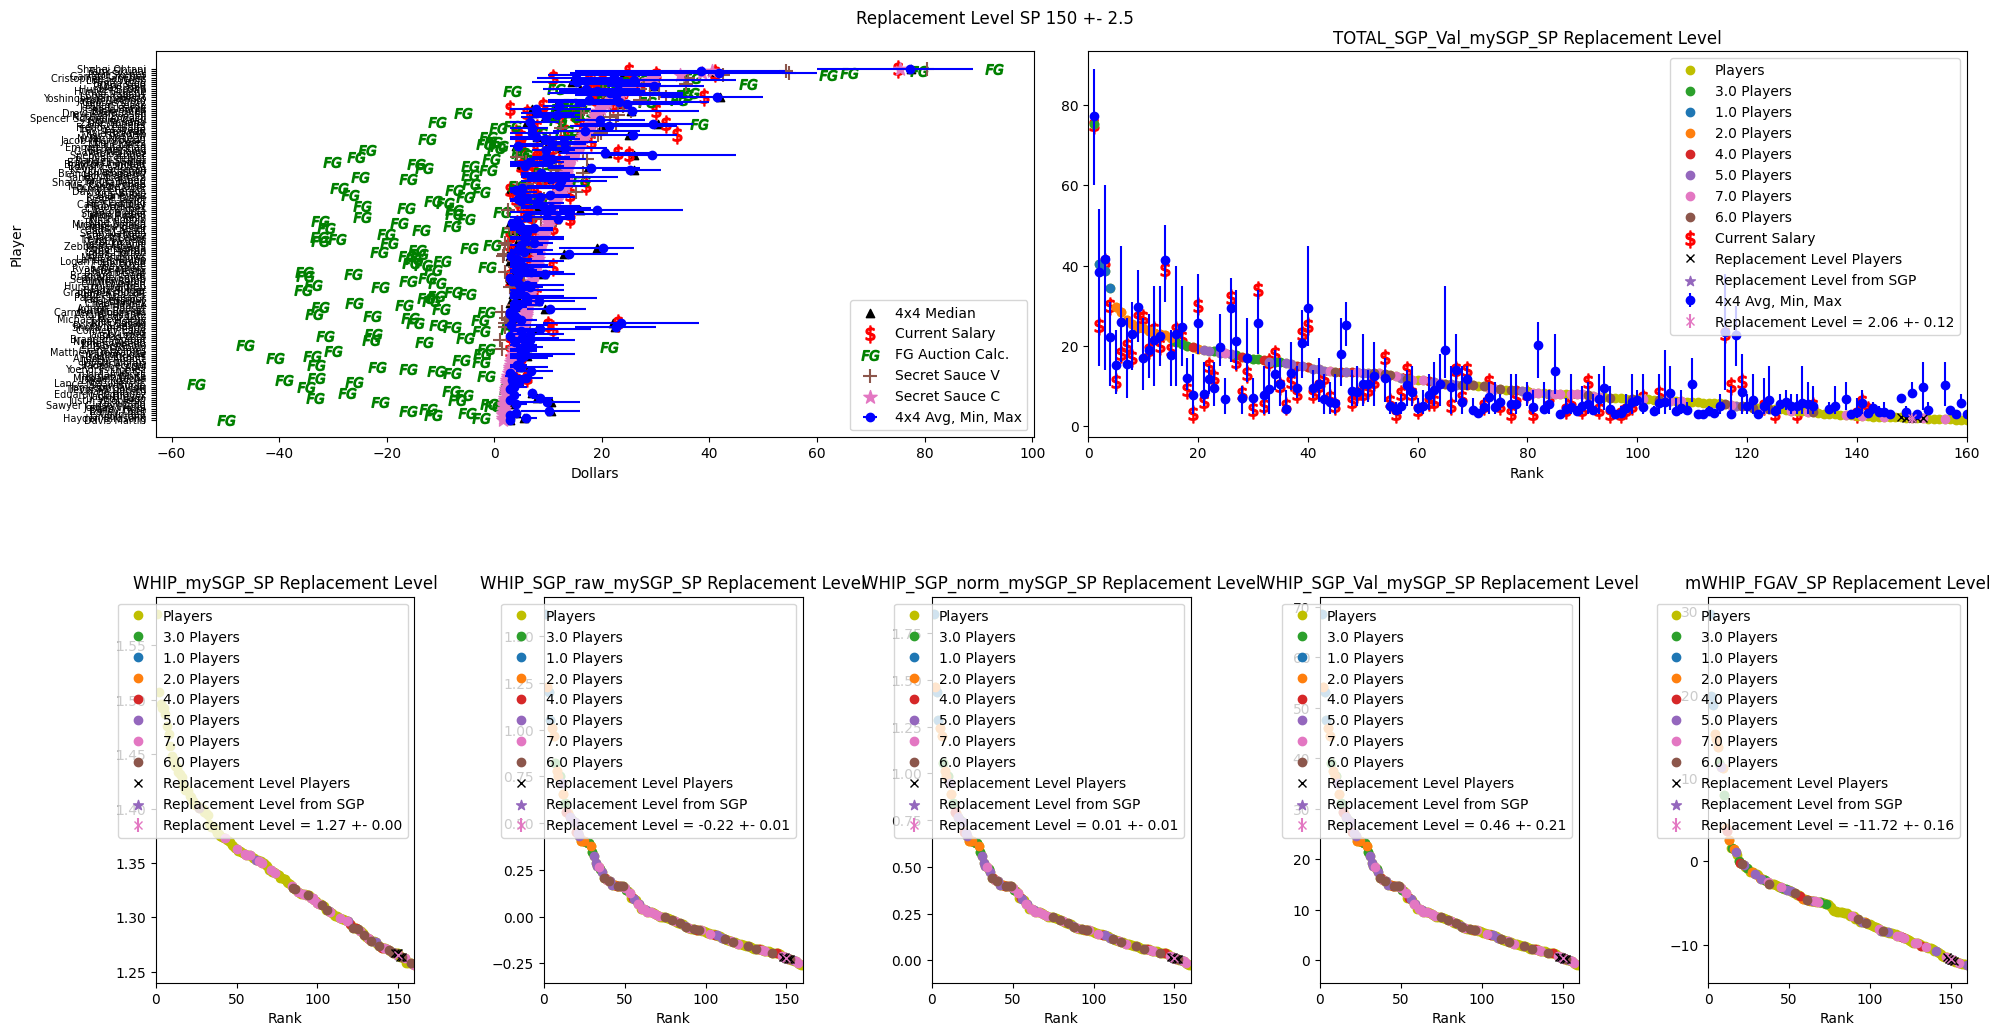

In [37]:
pos_idx = 0

Players_out = []#['45713']
Players_in = []#['21156']

Recalc_Replacement_Level = pd.DataFrame()

for pos,repl_level_mid in Replacement_Level.items():
    Hitter_or_Pitcher_sorted = Sorted_Pitcher_df

    This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.split('/'))]
    This_Pos_Repl_df = Both_Replacement_Level_df[Both_Replacement_Level_df['Ottoneu Positions'] == pos]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Hitter_or_Pitcher_sorted[~Hitter_or_Pitcher_sorted['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"2B" in x.split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"SS" in x.split('/'))]

        ]).sort_values(by=['TOTAL_SGP_Val_mySGP'])
        This_Pos_Repl_df = pd.DataFrame(Both_Replacement_Level_df.loc[Both_Replacement_Level_df[Both_Replacement_Level_df['Ottoneu Positions'].isin(['2B','SS'])]['TOTAL_SGP_raw_mySGP'].idxmin()]).T.reset_index(drop=True)

    if (This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)].shape[0] == 0) & \
        (This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)].shape[0] == 0) & \
            (len(Players_out)+ len(Players_in) > 0):

        continue

    Replacement_Stats_df = pd.DataFrame()
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    for score_cat,Stat_col_list in Pitching_value_columns.items():
        stat_idx = 0
        x_max = repl_level_mid+(2*Replacement_window[pos])
        fig0 = plt.figure(figsize=(20,10))
        outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
        upper_axes = outer_subfig[0].subplots(1, 2)
        lower_gs = outer_subfig[1].add_gridspec(1,len(Stat_col_list)-1, wspace=0.5)
        lower_axes = lower_gs.subplots(sharey=False) # Because ADP is above
        #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))

        for stat_col in Stat_col_list:
            this_axis = lower_axes[stat_idx-1]
            is_rank = False
            if 'TOTAL_SGP_Val_mySGP' == stat_col:
                this_axis = upper_axes[1]
            This_Pos_df[f'{stat_col}_{pos}_rank'] = This_Pos_df[f'{stat_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
            # this_axis = axs

            if stat_idx == 0:
                quick_plotting_fn(This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max],upper_axes[0])
            
            Replacement_level_df = This_Pos_df[(This_Pos_df[f'{stat_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{stat_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                                ].sort_values([f'{stat_col}_{pos}_rank'], ascending=is_rank)
            mean = Replacement_level_df[stat_col].mean()
            std = Replacement_level_df[stat_col].std()
            Replacement_Stats_df = pd.concat([
                Replacement_Stats_df,
                pd.DataFrame([{
                    'POS':pos,
                    'Stat': stat_col,
                    'mean':mean,
                    'std':std
                }])
            ])

            this_axis.plot(This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col], 'yo', label='Players')
            if This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)].shape[0] != 0:
                this_axis.plot(This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)][stat_col], 'r*', label='Player Out',markersize=15)
            if This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)].shape[0] != 0:
                this_axis.plot(This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)][stat_col], 'g*', label='Player In',markersize=15)
            for tier in list(This_Pos_df['Tier'].dropna().unique()):
                This_Pos_tier_df = This_Pos_df[This_Pos_df['Tier'] == tier]
                this_axis.plot(This_Pos_tier_df[This_Pos_tier_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],This_Pos_tier_df[This_Pos_tier_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col], marker='o', label=f'{tier} Players',color=my_cmap[tier],linestyle='')
            if (not is_rank) & (stat_idx == 0):
                this_axis.errorbar(
                    y=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                    x=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],
                    yerr=[
                        This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                        This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                    ],
                    fmt='o',
                    color='blue',
                    label='4x4 Avg, Min, Max'
                )
                this_axis.scatter(
                    y=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Salary'],
                    x=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],
                    marker='$\\$$',
                    color='red',
                    s=150,
                    label='Current Salary'
                )
            if (len(Replacement_level_df[Replacement_level_df[f'{stat_col}_{pos}_rank'] == repl_level_mid][f'{stat_col}_{pos}_rank']) > 0.):
                this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{stat_col}_{pos}_rank'] == repl_level_mid][f'{stat_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
                
                #print(f'Replacement Level {stat_col} {pos} {mean:0.2f} +- {std:0.2f}')
                #display(Replacement_level_df)
                #display(This_Pos_Repl_df.dropna(axis=1))
            this_axis.plot(Replacement_level_df[f'{stat_col}_{pos}_rank'],Replacement_level_df[stat_col], marker='x', color='k',label='Replacement Level Players',linestyle='')
            if stat_col in list(This_Pos_Repl_df.dropna(axis=1).columns):
                this_axis.scatter([repl_level_mid],[This_Pos_Repl_df.dropna(axis=1)[stat_col]], marker='*',color='tab:purple',label='Replacement Level from SGP', s=55)
            this_axis.set_title(f'{stat_col}_{pos} Replacement Level')
            #this_axis.set_ylabel(stat_col)
            this_axis.set_xlabel('Rank')
            # ymin = 0.95*This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col].min()
            # ymax = 1.05*This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col].max()
            xmin=0.
            xmax = x_max
            # this_axis.set_ylim([ymin,ymax])
            this_axis.set_xlim([xmin,xmax])
            this_axis.legend(loc='upper right')
            if is_rank:
                this_axis.legend(loc='upper left')

            #print(stat_col, mean, ' +- ', std)
            #print(Replacement_level_df.head(Replacement_window[pos]))
            # quick_plotting_fn(Replacement_level_df,this_axis)
            # plt.tight_layout()    
            # plt.show()
            #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
            stat_idx+=1
        pos_idx+=1   
        fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
        plt.tight_layout()
        plt.show()
        #fig0.savefig(League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Replacement_Level_{pos}_{score_cat}.png')
        #plt.close()
    Recalc_Replacement_Level = pd.concat([Recalc_Replacement_Level,Replacement_Stats_df.pivot_table('mean','POS','Stat')])